# RT-DETR - Inferencia con parches

Se aplica el proceso completo de inferencia (división en parches, predicción, traslado a coordenadas globales y filtro de duplicados) sobre las imágenes completas de test, para 
comparar el conteo de kanjis detectados con el número real.

In [1]:
from pathlib import Path
from ultralytics import YOLO


ruta_test_original = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_original/images/test")
ruta_labels_original = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_original/labels/test")
ruta_modelo_rtdetr_original = "/home/salvarado/TFM/resultados/result_RT_DTR/parches_original_1024_50ep_RT_DTR/weights/best.pt"

modelo_rtdetr_original = YOLO(ruta_modelo_rtdetr_original)

print("Modelo  cargado")


ruta_test_denoised = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_denoised/images/test")
ruta_labels_denoised = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_denoised/labels/test")
ruta_modelo_rtdetr_denoised = "/home/salvarado/TFM/resultados/result_RT_DTR/parches_denoised_1024_50ep_RT_DTR/weights/best.pt"

model_rtdetr_denoised = YOLO(ruta_modelo_rtdetr_denoised)
print("Modelo denoised cargado")




Modelo  cargado
Modelo denoised cargado


## Definicion de parametros de inferencia

In [2]:
patch_size = 2048
overlap = 512
step = patch_size - overlap  
imgsz = 1024
conf = 0.5

print("Parámetros definidos")
print("Parámetros listos")
print("Patch size:", patch_size)
print("Overlap:", overlap)
print("Step:", step)
print("Conf:", conf)
print("imgsz:", imgsz)

Parámetros definidos
Parámetros listos
Patch size: 2048
Overlap: 512
Step: 1536
Conf: 0.5
imgsz: 1024


In [3]:
def calcular_iou(caja1, caja2):
    """Calcula el IoU entre dos cajas [x1, y1, x2, y2]."""
    x1 = max(caja1[0], caja2[0])
    y1 = max(caja1[1], caja2[1])
    x2 = min(caja1[2], caja2[2])
    y2 = min(caja1[3], caja2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    interseccion = inter_w * inter_h

    area1 = (caja1[2] - caja1[0]) * (caja1[3] - caja1[1])
    area2 = (caja2[2] - caja2[0]) * (caja2[3] - caja2[1])
    union = area1 + area2 - interseccion

    return interseccion / union if union > 0 else 0


def evaluar_deteccion(reales, detectadas, umbral_iou=0.5):
    """
    Empareja detecciones con cajas reales por IoU.
    reales, detectadas: listas de [x1, y1, x2, y2]
    Devuelve: TP, FP, FN
    """
    reales_usadas = [False] * len(reales)
    tp = 0
    fp = 0

    for caja_det in detectadas:
        mejor_iou = 0
        mejor_idx = -1
        for i, caja_real in enumerate(reales):
            if reales_usadas[i]:
                continue
            iou = calcular_iou(caja_det, caja_real)
            if iou > mejor_iou:
                mejor_iou = iou
                mejor_idx = i

        if mejor_iou >= umbral_iou:
            tp += 1
            reales_usadas[mejor_idx] = True
        else:
            fp += 1

    fn = reales_usadas.count(False)
    return tp, fp, fn

print("Funciones de evaluación por IoU cargadas")

Funciones de evaluación por IoU cargadas


## Inferencia con parches y filtro de duplicados (RT-DETR Original 1024)

RESULTADOS RT-DETR ORIGINAL 1024
Imagen                           Reales     TP     FP     FN  Precisión   Recall
-------------------------------------------------------------------------------------
sakuma-0447_Page_02                 152    113     22     39      0.837    0.743
sakuma-0451_Page_26                 323    261     21     62      0.926    0.808
sakuma-0469_Page_09                 259    207     31     52      0.870    0.799
sakuma-0469_Page_13                 229    176     28     53      0.863    0.769
sakuma-0470_Page_07                 260    188     11     72      0.945    0.723
sakuma-0513_Page_03                 100     81      6     19      0.931    0.810
sakuma-0513_Page_06                 321    264     45     57      0.854    0.822
sakuma-0581_Page_12                 237    215     11     22      0.951    0.907
sakuma-0581_Page_19                 250    214     18     36      0.922    0.856
sakuma-0581_Page_29                 129    109     15     20      0.879

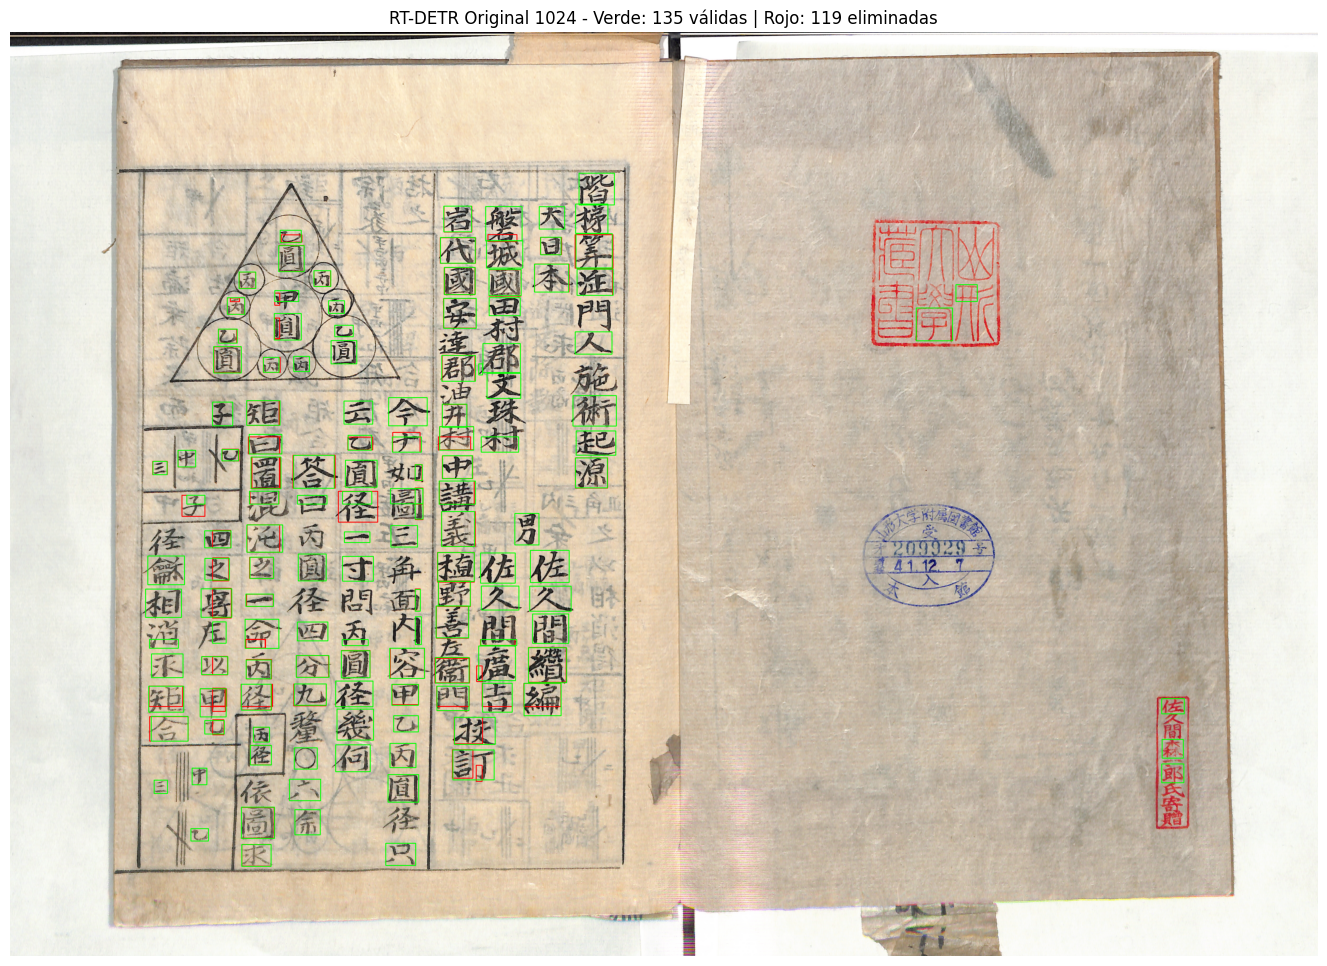

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2, glob, os

test_paths = sorted(glob.glob(str(ruta_test_original) + "/*.png"))

print("RESULTADOS RT-DETR ORIGINAL 1024")
print(f"{'Imagen':<30} {'Reales':>8} {'TP':>6} {'FP':>6} {'FN':>6} {'Precisión':>10} {'Recall':>8}")
print("-" * 85)

resultados_rtdetr_original = []

imagen_visual = None
buenas_visual = None
eliminadas_visual = None

for img_path in test_paths:
    imagen = cv2.imread(img_path)
    alto, ancho = imagen.shape[:2]
    nombre = os.path.basename(img_path).replace(".png", "")

    # Cargar cajas reales (coordenadas, no solo el conteo)
    label_path = str(ruta_labels_original / (nombre + ".txt"))
    reales = []
    with open(label_path) as f:
        for linea in f:
            datos = linea.split()
            cx = float(datos[1]) * ancho
            cy = float(datos[2]) * alto
            bw = float(datos[3]) * ancho
            bh = float(datos[4]) * alto
            reales.append([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2])
    n_reales = len(reales)

    # Detectar en parches
    todas_cajas = []

    for y in range(0, alto, step):
        for x in range(0, ancho, step):
            parche = imagen[y:y+patch_size, x:x+patch_size]

            if parche.shape[0] < 1000 or parche.shape[1] < 1000:
                continue

            res = modelo_rtdetr_original.predict(
                source=parche,
                conf=conf,
                imgsz=imgsz,
                device=1,
                verbose=False
            )

            for box in res[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                todas_cajas.append([x1+x, y1+y, x2+x, y2+y, float(box.conf[0])])

    # Filtrar duplicados
    cajas_ordenadas = sorted(todas_cajas, key=lambda c: c[4], reverse=True)

    buenas = []
    eliminadas = []

    for caja in cajas_ordenadas:
        duplicada = False

        for guardada in buenas:
            x1 = max(caja[0], guardada[0])
            y1 = max(caja[1], guardada[1])
            x2 = min(caja[2], guardada[2])
            y2 = min(caja[3], guardada[3])

            inter = max(0, x2-x1) * max(0, y2-y1)

            area_caja = (caja[2]-caja[0]) * (caja[3]-caja[1])
            area_guardada = (guardada[2]-guardada[0]) * (guardada[3]-guardada[1])
            area_menor = min(area_caja, area_guardada)

            if area_menor > 0 and inter / area_menor > 0.5:
                duplicada = True
                break

        if duplicada:
            eliminadas.append(caja)
        else:
            buenas.append(caja)

    # Evaluación por IoU contra el ground truth
    detectadas = [c[:4] for c in buenas]
    tp, fp, fn = evaluar_deteccion(reales, detectadas, umbral_iou=0.5)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    resultados_rtdetr_original.append({
        "imagen": nombre,
        "reales": n_reales,
        "sin_filtro": len(todas_cajas),
        "con_filtro": len(buenas),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": round(precision, 3),
        "recall": round(recall, 3)
    })

    print(f"{nombre:<30} {n_reales:>8} {tp:>6} {fp:>6} {fn:>6} {precision:>10.3f} {recall:>8.3f}")

    # Guardar una imagen para visualizar el filtro
    if imagen_visual is None:
        imagen_visual = imagen
        buenas_visual = buenas
        eliminadas_visual = eliminadas
        nombre_visual = nombre

# Visualización del filtro
dibujo = imagen_visual.copy()

for x1, y1, x2, y2, c in eliminadas_visual:
    cv2.rectangle(dibujo, (x1, y1), (x2, y2), (0, 0, 255), 6)

for x1, y1, x2, y2, c in buenas_visual:
    cv2.rectangle(dibujo, (x1, y1), (x2, y2), (0, 255, 0), 6)

plt.figure(figsize=(18, 12))
plt.imshow(cv2.cvtColor(dibujo, cv2.COLOR_BGR2RGB))
plt.title(f"RT-DETR Original 1024 - Verde: {len(buenas_visual)} válidas | Rojo: {len(eliminadas_visual)} eliminadas")
plt.axis("off")
plt.show()

### Análisis

En la imagen se ven las detecciones de RT-DETR sobre sakuma-0447_Page_02 después de aplicar la inferencia con parches y el filtro de duplicados. Las cajas verdes representan las detecciones que se consideran válidas tras el filtro, y las rojas son las que se eliminaron por solaparse en más de un 50% con otra detección.

Se puede ver que el filtro funciona bien, ya que elimina las detecciones repetidas que aparecen en las zonas donde los parches se solapan. Evaluando estas detecciones frente al ground truth mediante IoU, de los 152 kanjis reales de esta página se identificaron correctamente 113 (verdaderos positivos), mientras que 39 kanjis quedaron sin detectar (falsos negativos) y 22 detecciones no se correspondían con ningún kanji real (falsos positivos), resultando en una precisión de 0,837 y un recall de 0,743. Esto es coherente con el comportamiento general de RT-DETR observado en la Tabla 6.7, donde su rendimiento se mantiene por debajo del de YOLO incluso aplicando el pipeline completo.

---

## Inferencia con parches y filtro de duplicados (RT-DETR Denoised 1024)

RESULTADOS RT-DETR DENOISED 1024
Imagen                           Reales     TP     FP     FN  Precisión   Recall
-------------------------------------------------------------------------------------
sakuma-0447_Page_02denoised         152    137     25     15      0.846    0.901
sakuma-0451_Page_26denoised         323    285     22     38      0.928    0.882
sakuma-0469_Page_09denoised         259    241     17     18      0.934    0.931
sakuma-0469_Page_13denoised         229    203     12     26      0.944    0.886
sakuma-0470_Page_07denoised         260    251      5      9      0.980    0.965
sakuma-0513_Page_03denoised         100     80      9     20      0.899    0.800
sakuma-0513_Page_06denoised         321    292     22     29      0.930    0.910
sakuma-0581_Page_12denoised         237    227      5     10      0.978    0.958
sakuma-0581_Page_19denoised         250    234      8     16      0.967    0.936
sakuma-0581_Page_29denoised         129    120     10      9      0.923

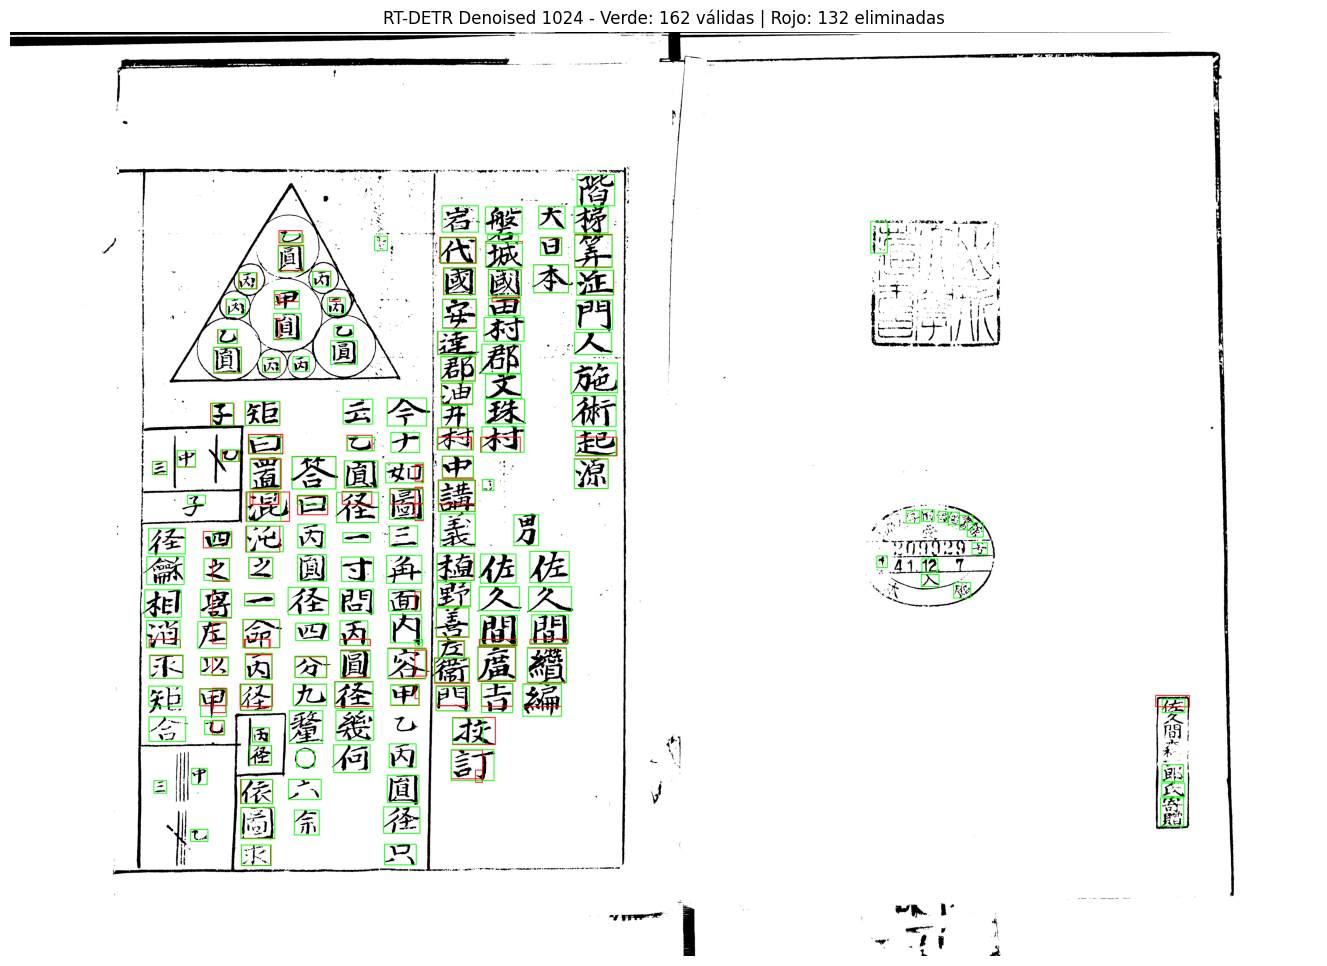

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2, glob, os

test_paths = sorted(glob.glob(str(ruta_test_denoised) + "/*.png"))

print("RESULTADOS RT-DETR DENOISED 1024")
print(f"{'Imagen':<30} {'Reales':>8} {'TP':>6} {'FP':>6} {'FN':>6} {'Precisión':>10} {'Recall':>8}")
print("-" * 85)

resultados_rtdetr_denoised = []

imagen_visual = None
buenas_visual = None
eliminadas_visual = None

for img_path in test_paths:
    imagen = cv2.imread(img_path)
    alto, ancho = imagen.shape[:2]
    nombre = os.path.basename(img_path).replace(".png", "")

    # Cargar cajas reales (coordenadas, no solo el conteo)
    label_path = str(ruta_labels_denoised / (nombre + ".txt"))
    reales = []
    with open(label_path) as f:
        for linea in f:
            datos = linea.split()
            cx = float(datos[1]) * ancho
            cy = float(datos[2]) * alto
            bw = float(datos[3]) * ancho
            bh = float(datos[4]) * alto
            reales.append([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2])
    n_reales = len(reales)

    todas_cajas = []

    for y in range(0, alto, step):
        for x in range(0, ancho, step):
            parche = imagen[y:y+patch_size, x:x+patch_size]

            if parche.shape[0] < 1000 or parche.shape[1] < 1000:
                continue

            res = model_rtdetr_denoised.predict(
                source=parche,
                conf=conf,
                imgsz=imgsz,
                device=1,
                verbose=False
            )

            for box in res[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                todas_cajas.append([x1+x, y1+y, x2+x, y2+y, float(box.conf[0])])

    cajas_ordenadas = sorted(todas_cajas, key=lambda c: c[4], reverse=True)

    buenas = []
    eliminadas = []

    for caja in cajas_ordenadas:
        duplicada = False
        for guardada in buenas:
            x1 = max(caja[0], guardada[0])
            y1 = max(caja[1], guardada[1])
            x2 = min(caja[2], guardada[2])
            y2 = min(caja[3], guardada[3])

            inter = max(0, x2-x1) * max(0, y2-y1)
            area_caja = (caja[2]-caja[0]) * (caja[3]-caja[1])
            area_guardada = (guardada[2]-guardada[0]) * (guardada[3]-guardada[1])
            area_menor = min(area_caja, area_guardada)

            if area_menor > 0 and inter / area_menor > 0.5:
                duplicada = True
                break

        if duplicada:
            eliminadas.append(caja)
        else:
            buenas.append(caja)

    # Evaluación por IoU contra el ground truth
    detectadas = [c[:4] for c in buenas]
    tp, fp, fn = evaluar_deteccion(reales, detectadas, umbral_iou=0.5)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    resultados_rtdetr_denoised.append({
        "imagen": nombre,
        "reales": n_reales,
        "sin_filtro": len(todas_cajas),
        "con_filtro": len(buenas),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": round(precision, 3),
        "recall": round(recall, 3)
    })

    print(f"{nombre:<30} {n_reales:>8} {tp:>6} {fp:>6} {fn:>6} {precision:>10.3f} {recall:>8.3f}")

    if imagen_visual is None:
        imagen_visual = imagen
        buenas_visual = buenas
        eliminadas_visual = eliminadas
        nombre_visual = nombre

dibujo = imagen_visual.copy()

for x1, y1, x2, y2, c in eliminadas_visual:
    cv2.rectangle(dibujo, (x1, y1), (x2, y2), (0, 0, 255), 6)

for x1, y1, x2, y2, c in buenas_visual:
    cv2.rectangle(dibujo, (x1, y1), (x2, y2), (0, 255, 0), 6)

plt.figure(figsize=(18, 12))
plt.imshow(cv2.cvtColor(dibujo, cv2.COLOR_BGR2RGB))
plt.title(f"RT-DETR Denoised 1024 - Verde: {len(buenas_visual)} válidas | Rojo: {len(eliminadas_visual)} eliminadas")
plt.axis("off")
plt.show()